In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [10]:
df = pd.read_csv('/content/drive/MyDrive/AI_ML/NLP/Hotel_Reviews.csv')

In [12]:
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [14]:
print(df.columns)

Index(['Review', 'Rating'], dtype='object')


In [17]:
X = df['Review']
y = df['Rating']

In [ ]:
X = X.fillna('')

In [18]:
print(y.value_counts())

Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64


In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [20]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [21]:
print("Training Size:", len(X_train))
print("Validation Size:", len(X_val))
print("Test Size:", len(X_test))

Training Size: 14343
Validation Size: 3074
Test Size: 3074


In [23]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=30000
)

In [24]:
X_train_tfidf = vectorizer.fit_transform(X_train)

X_val_tfidf = vectorizer.transform(X_val)

X_test_tfidf = vectorizer.transform(X_test)

In [25]:
print(X_train_tfidf.shape)
print(X_val_tfidf.shape)
print(X_test_tfidf.shape)

(14343, 30000)
(3074, 30000)
(3074, 30000)


In [26]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [27]:
y_val_pred = model.predict(X_val_tfidf)

In [28]:
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.6132075471698113


In [29]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           1       0.71      0.65      0.68       213
           2       0.43      0.31      0.36       269
           3       0.48      0.23      0.31       327
           4       0.51      0.52      0.51       906
           5       0.70      0.82      0.76      1359

    accuracy                           0.61      3074
   macro avg       0.56      0.51      0.52      3074
weighted avg       0.60      0.61      0.60      3074



In [30]:
y_test_pred = model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.6076772934287573


In [31]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           1       0.74      0.62      0.68       213
           2       0.47      0.36      0.41       269
           3       0.42      0.21      0.28       328
           4       0.50      0.51      0.50       906
           5       0.69      0.82      0.75      1358

    accuracy                           0.61      3074
   macro avg       0.57      0.50      0.52      3074
weighted avg       0.59      0.61      0.59      3074



In [32]:
samples = [
    "room was spotless staff were incredibly friendly loved every minute",
    "great location comfortable beds breakfast decent but nothing special",
    "hotel was average room small parking difficult but overall okay",
    "room was dirty and noisy air conditioning broken staff unhelpful",
    "absolutely terrible experience worst hotel ever rude staff disgusting bathroom"
]

for review in samples:
    vec = vectorizer.transform([review])
    pred = model.predict(vec)[0]
    print(f"★{pred}  →  {review[:55]}...")

★5  →  room was spotless staff were incredibly friendly loved ...
★3  →  great location comfortable beds breakfast decent but no...
★3  →  hotel was average room small parking difficult but over...
★1  →  room was dirty and noisy air conditioning broken staff ...
★1  →  absolutely terrible experience worst hotel ever rude st...


In [33]:
print(df.shape)

(20491, 2)


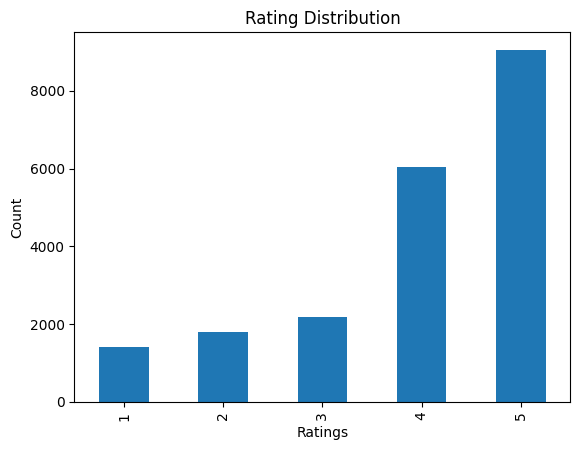

In [34]:
import matplotlib.pyplot as plt

y.value_counts().sort_index().plot(kind='bar')

plt.xlabel("Ratings")
plt.ylabel("Count")
plt.title("Rating Distribution")

plt.show()

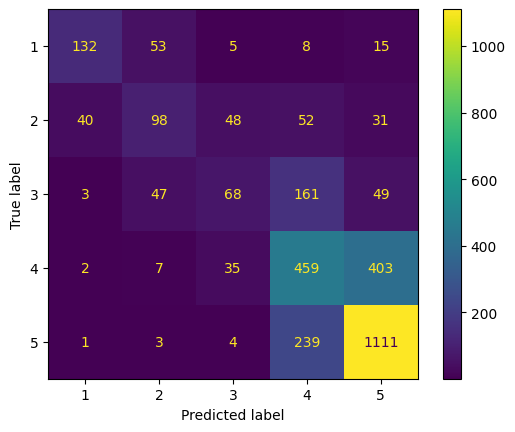

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[1, 2, 3, 4, 5]  # ← this is all you need
)

disp.plot()

The project successfully predicted Hotel review ratings using TF-IDF and Logistic Regression. The dataset was divided into training, validation, and test sets. The model achieved approximately 61% accuracy. Positive reviews were predicted more accurately than neutral reviews.